# Análisis estadístico de la categoría TV & Video displays

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr
import seaborn as sns
import plotly.express as px
from tqdm import tqdm
from scipy.stats import mannwhitneyu
from IPython.display import HTML


In [2]:
df_tv_and_video_displays = pd.read_csv('../Datasets/amazon_final.csv')
df_tv_and_video_displays = df_tv_and_video_displays[df_tv_and_video_displays['product_category'] == 'TV & Video Displays']
df_tv_and_video_displays.head()

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,coupon,buy_box_availability,sustainability_tags,product_image_url,has_coupon,product_category,discount_percentage
19,Roku Streaming Stick HD 2025 — HD Streaming De...,4.6,1909.0,10000.0,33.51,33.51,No Badge,Organic,No Coupon,0,Works with Alexa,https://m.media-amazon.com/images/I/71mye7IQ5j...,0,TV & Video Displays,0.00
33,Texas Instruments TI-30XS MultiView Scientific...,4.8,36122.0,70000.0,16.99,20.00,No Badge,Organic,No Coupon,1,NaN,https://m.media-amazon.com/images/I/71b23YXk+R...,0,TV & Video Displays,15.05
35,Mounting Dream TV Wall Mount for 32-65 Inch Te...,4.8,44109.0,10000.0,39.97,48.99,Best Seller,Organic,No Coupon,1,NaN,https://m.media-amazon.com/images/I/61da4dQI-h...,0,TV & Video Displays,18.41
63,VIZIO 40-inch Full HD 1080p Smart TV with DTS ...,4.1,4856.0,10000.0,138.00,169.99,Best Seller,Organic,No Coupon,1,NaN,https://m.media-amazon.com/images/I/81NLMdXhvr...,0,TV & Video Displays,18.82
68,Roku Streaming Stick Plus 2025 - 4K & HDR Roku...,4.5,744.0,10000.0,44.99,44.99,No Badge,Organic,No Coupon,0,Works with Alexa,https://m.media-amazon.com/images/I/71gFPvNe5K...,0,TV & Video Displays,0.00


In [3]:
def info_df(df):
    return pd.DataFrame({
    'Columna': df.columns,
    'No Nulos': df.notnull().sum().values,
    'Nulos': df.isnull().sum().values,
    'Tipo Python': df.dtypes.values,
    'Núm. valores': [len(df[col].unique()) for col in df.columns]
     })
info = info_df(df_tv_and_video_displays)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,product_title,2891,0,object,605
1,product_rating,2885,6,float64,21
2,total_reviews,2885,6,float64,517
3,purchased_last_month,2086,805,float64,17
4,discounted_price,2830,61,float64,414
5,original_price,2830,61,float64,378
6,is_best_seller,2891,0,object,5
7,is_sponsored,2891,0,object,2
8,coupon,2891,0,object,4
9,buy_box_availability,2891,0,int64,2


### Gráficas sobre variables relevantes individuales

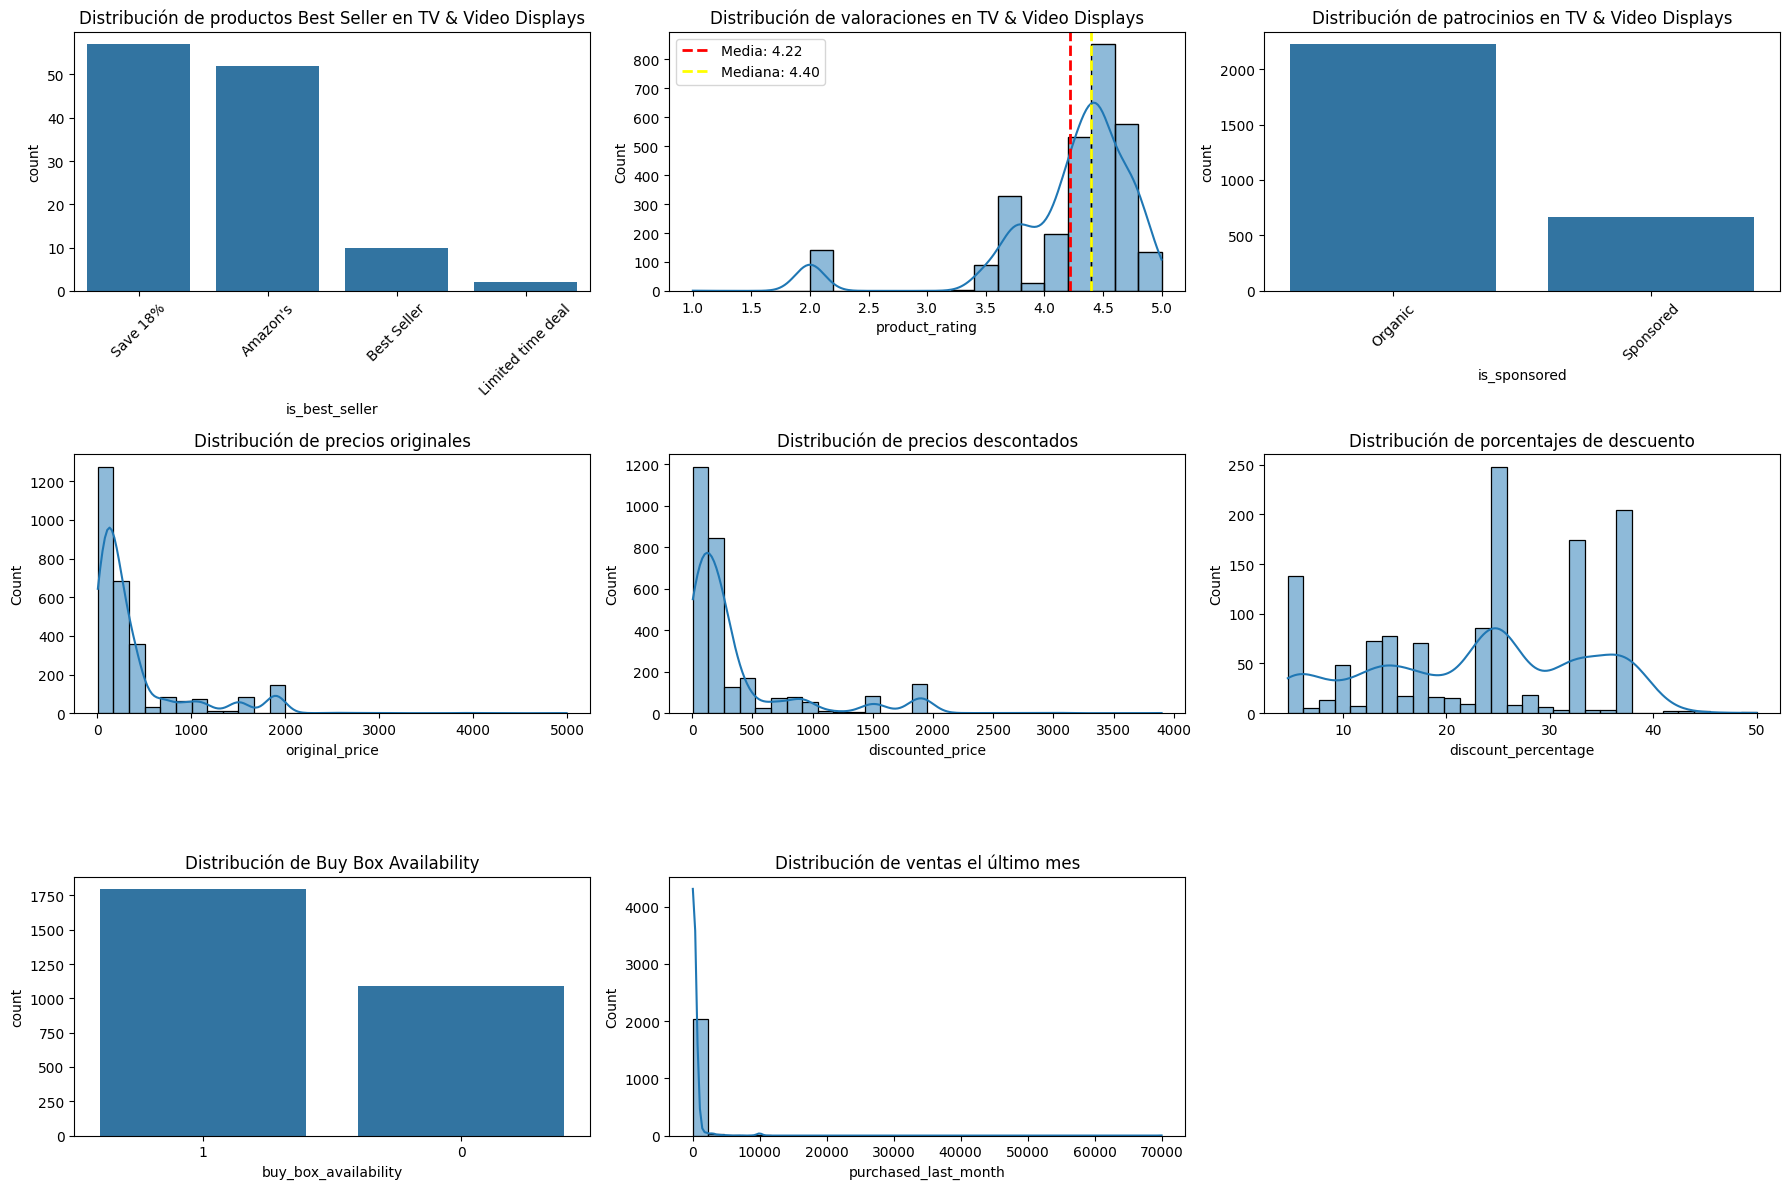

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

# 1. Distribución de Best Seller
ax = axes[0][0]
tv_sin_noBadge = df_tv_and_video_displays[df_tv_and_video_displays['is_best_seller'] != 'No Badge']

sns.countplot(
    data=tv_sin_noBadge,
    x='is_best_seller',
    order=tv_sin_noBadge['is_best_seller'].value_counts().index,
    ax=ax
)
ax.set_title('Distribución de productos Best Seller en TV & Video Displays')
ax.tick_params(axis='x', rotation=45)

# 2. Distribución de ratings
ax = axes[0][1]
sns.histplot(df_tv_and_video_displays['product_rating'].dropna(), bins=20, kde=True, ax=ax)
media = df_tv_and_video_displays['product_rating'].mean()
mediana = df_tv_and_video_displays['product_rating'].median()
ax.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
ax.axvline(mediana, color='yellow', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.2f}')
ax.set_title('Distribución de valoraciones en TV & Video Displays')
ax.legend()

# 3. Distribución de patrocinios
ax = axes[0][2]
sns.countplot(
    data=df_tv_and_video_displays,
    x='is_sponsored',
    order=df_tv_and_video_displays['is_sponsored'].value_counts().index,
    ax=ax
)
ax.set_title('Distribución de patrocinios en TV & Video Displays')
ax.tick_params(axis='x', rotation=45)

# 4. Precios originales
ax = axes[1][0]
sns.histplot(df_tv_and_video_displays['original_price'].dropna(), bins=30, kde=True, ax=ax)
ax.set_title('Distribución de precios originales')

# 5. Precios descontados
ax = axes[1][1]
sns.histplot(df_tv_and_video_displays['discounted_price'].dropna(), bins=30, kde=True, ax=ax)
ax.set_title('Distribución de precios descontados')

# 6. Porcentajes de descuento (solo > 0)
ax = axes[1][2]
sns.histplot(
    df_tv_and_video_displays[df_tv_and_video_displays['discount_percentage'] > 0]['discount_percentage'].dropna(),
    bins=30, kde=True, ax=ax
)
ax.set_title('Distribución de porcentajes de descuento')

# 7. Buy Box availability
ax = axes[2][0]
sns.countplot(
    data=df_tv_and_video_displays,
    x='buy_box_availability',
    order=df_tv_and_video_displays['buy_box_availability'].value_counts().index,
    ax=ax
)
ax.set_title('Distribución de Buy Box Availability')
ax.tick_params(axis='x', rotation=0)

# 8. Ventas último mes
ax = axes[2][1]
sns.histplot(df_tv_and_video_displays['purchased_last_month'].dropna(), bins=30, kde=True, ax=ax)
ax.set_title('Distribución de ventas el último mes')

# 9. Ocultar el último subplot (para que quede como en Audio)
axes[2][2].set_visible(False)

plt.tight_layout()
plt.show()


## Análisis descriptivo de la categoría *TV & Video Displays*

La categoría *TV & Video Displays* presenta particularidades propias, como un amplio rango de precios y una elevada dependencia de la percepción de calidad por parte del consumidor, lo que justifica un análisis específico de sus principales variables comerciales.

A continuación, se presenta un análisis descriptivo de las variables asociadas a los productos pertenecientes a esta categoría, basado en las distribuciones observadas en las Figuras anteriores.

### 1. Distribución de productos *Best Seller*
La mayoría de los productos de la categoría *TV & Video Displays* no presenta ninguna distinción especial destacada por Amazon. Las etiquetas como *Save 18%*, *Amazon’s Choice*, *Best Seller* o promociones de tiempo limitado aparecen repartidas entre un subconjunto reducido de productos. Esto sugiere un mercado altamente competitivo, en el que distintas estrategias comerciales conviven sin que una sola domine claramente la visibilidad de los productos.

### 2. Distribución de valoraciones (*Rating*)
Las valoraciones de los televisores son, en general, elevadas. La media se sitúa en torno a **4.22**, mientras que la mediana alcanza un valor de **4.40**, lo que indica que la mayoría de los productos bien posicionados cuenta con una valoración positiva por parte de los usuarios. Este comportamiento resulta especialmente relevante en productos de alto coste, donde el riesgo percibido por el consumidor es mayor y las valoraciones juegan un papel determinante en la decisión de compra. Aun así, los productos con valoraciones bajas quedan claramente penalizados en términos de competitividad.

### 3. Distribución de patrocinios (*Is\_sponsored*)
La mayor parte de los productos de esta categoría aparece de forma orgánica, sin patrocinio. Aunque existe un número relevante de productos patrocinados, estos representan una minoría del total. Este comportamiento sugiere que los precios observados responden principalmente a dinámicas de mercado reales y no están fuertemente condicionados por estrategias publicitarias de pago.

### 4. Distribución de precios (*Originales* y *Descontados*)
La distribución de precios presenta una fuerte asimetría positiva. La mayoría de los televisores se concentra en rangos de precio bajos y medios, mientras que existe una cola derecha asociada a modelos de gama alta o premium. Esta estructura de precios sugiere una segmentación clara del mercado entre productos de consumo general y modelos orientados a un público especializado o profesional.

### 5. Distribución de porcentajes de descuento
Los porcentajes de descuento muestran una variabilidad considerable. Se observa la coexistencia de descuentos moderados, orientados a preservar márgenes de beneficio, junto con descuentos más agresivos aplicados a determinados productos. Esto indica la aplicación de distintas estrategias comerciales, ya sea para estimular la demanda o para facilitar la rotación de stock en modelos concretos.

### 6. Distribución de *Buy Box Availability*
La mayoría de los productos dispone del botón de compra activo (*Buy Box*), lo que indica disponibilidad y condiciones competitivas adecuadas. No obstante, existe un grupo significativo de productos que no cuenta con esta opción, lo que puede estar relacionado con problemas de stock, precios poco competitivos o políticas internas de Amazon que penalizan determinadas ofertas.

### 7. Distribución de ventas en el último mes (*Purchased Last Month*)
La distribución de las ventas en el último mes sigue un patrón altamente concentrado. Un número reducido de televisores acumula un volumen elevado de compras, mientras que la mayoría presenta cifras de ventas modestas. Este patrón es consistente con mercados digitales altamente competitivos, donde la visibilidad y el posicionamiento inicial generan efectos de arrastre que benefician a un número limitado de productos.

### 8. Síntesis del análisis descriptivo
El análisis descriptivo de la categoría *TV & Video Displays* revela un mercado altamente competitivo, caracterizado por una fuerte concentración de ventas, una elevada exigencia en términos de valoración y una clara segmentación de precios. Estos resultados sugieren que factores como la reputación del producto, la visibilidad y las estrategias de descuento desempeñan un papel clave en el rendimiento comercial de los televisores en el entorno de Amazon.

---

Cabe destacar que este análisis se basa en datos transversales y en una estimación aproximada del volumen de ventas, por lo que los resultados deben interpretarse como patrones generales y no como relaciones causales.


# Outliers y relación entre variables

In [5]:
fig = px.box(
    df_tv_and_video_displays,
    x="original_price",
    y="is_sponsored",
    width=1000,
    height=500,
    title="Precio original vs patrocinio en TV & Video Displays"
)
fig.show()


**Interpretación (precio original vs patrocinio).** El diagrama de caja muestra una diferencia clara entre productos *Sponsored* y *Organic*. Los productos patrocinados se concentran en rangos de precio bajos/medios y presentan menor dispersión, mientras que los productos orgánicos exhiben una variabilidad mucho mayor y acumulan los valores extremos (outliers), alcanzando precios muy elevados. Esto sugiere que, dentro de *TV & Video Displays*, el patrocinio se utiliza principalmente en productos de precio más contenido, mientras que las ofertas premium/profesionales aparecen mayoritariamente de forma orgánica.


In [6]:
df_tv_and_video_displays[
    df_tv_and_video_displays['original_price'] > 3000
][['product_title', 'original_price', 'is_sponsored']].sort_values(
    by='original_price', ascending=False
)


,product_title,original_price,is_sponsored
13361,Poly Studio X52 All-in-One Video Bar with TC10...,4995.95,Organic
3313,Logitech Rally Bar All-in-One Video Bar for Me...,4199.00,Organic
7847,Sony FE 50-150 F2 GM,3898.00,Organic
8744,Sony FE 50-150 F2 GM,3898.00,Organic
4449,Hisense PX3-PRO Ultra Short Throw Triple Laser...,3497.97,Organic
10515,Epson PowerLite L530U Long Throw 3LCD Projector,3090.15,Organic


**Identificación de valores extremos.** La inspección de los productos con precios superiores a 3.000 euros muestra que todos ellos corresponden a ofertas no patrocinadas y a dispositivos orientados a un uso profesional o corporativo. Estos casos constituyen outliers claros dentro de la distribución de precios y justifican su tratamiento diferenciado en análisis posteriores, con el fin de evitar distorsiones en el estudio del mercado de consumo.


### *Valoraciones vs patrocinio*

In [7]:
fig = px.box(
    df_tv_and_video_displays,
    x="product_rating",
    y="is_sponsored",
    width=1000,
    height=500,
    title="Valoraciones vs patrocinio en TV & Video Displays"
)
fig.show()


**Interpretación (valoraciones vs patrocinio).** El diagrama de caja muestra que tanto los productos patrocinados como los orgánicos presentan valoraciones mayoritariamente elevadas, concentradas en torno a valores superiores a 4 estrellas. No obstante, los productos orgánicos exhiben una mayor dispersión y la presencia de outliers con valoraciones muy bajas, mientras que los productos patrocinados presentan una distribución más homogénea. Este resultado sugiere que el patrocinio no implica necesariamente mejores valoraciones, pero sí una mayor consistencia en la percepción de calidad por parte de los consumidores.


### Precio original por frupos de valoración y patrocinio

In [8]:
bins = [0, 1, 2, 3, 4, 5]
labels = ['0–1', '1–2', '2–3', '3–4', '4–5']

df_tv_and_video_displays['rating_group'] = pd.cut(
    df_tv_and_video_displays['product_rating'],
    bins=bins,
    labels=labels,
    include_lowest=True
)


In [9]:
fig = px.box(
    df_tv_and_video_displays,
    x='original_price',
    y='rating_group',
    color='is_sponsored',
    width=1100,
    height=600,
    title='Precio original por grupos de valoración y patrocinio'
)
fig.show()


**Interpretación (precio por grupos de valoración y patrocinio).** La segmentación de los productos por tramos de valoración muestra que los productos con ratings elevados (4–5) abarcan todo el rango de precios, incluyendo tanto productos de consumo general como modelos de gama alta. Por el contrario, los productos con valoraciones bajas se concentran mayoritariamente en rangos de precio bajos o medios y no aparecen entre los productos de mayor coste. Asimismo, el patrocinio se observa principalmente en los tramos de valoración más altos, lo que sugiere que estas estrategias comerciales se aplican preferentemente a productos consolidados y bien valorados.


In [10]:
# Seleccionamos los productos con ventas extremas
top_sales = df_tv_and_video_displays[
    df_tv_and_video_displays['purchased_last_month'] > 5000
][[
    'product_title',
    'product_image_url',
    'purchased_last_month',
    'original_price',
    'product_rating'
]].sort_values(by='purchased_last_month', ascending=False)


In [11]:
def render_image(url):
    return f'<img src="{url}" width="80">'


In [12]:
HTML(
    top_sales.to_html(
        escape=False,
        formatters={'product_image_url': render_image},
        index=False
    )
)


product_title,product_image_url,purchased_last_month,original_price,product_rating
Texas Instruments TI-30XS MultiView Scientific Calculator,,70000.0,20.00,4.8
"Roku Streaming Stick HD 2025 — HD Streaming Device for TV with Roku Voice Remote, Free & Live TV",,10000.0,33.51,4.6
"Philips 22 inch Class Thin Full HD (1920 x 1080) Monitor, 100Hz Refresh Rate, VESA, HDMI x1, VGA x1, LowBlue Mode, Adaptive Sync, 4 Year Advance Replacement Warranty, 221V8LB",,10000.0,67.20,4.6
"Mounting Dream TV Wall Mount for 32-65 Inch Television,Mount with Swivel and Tilt, Full Motion Bracket with Articulating Dual Arms, Fits 16inch Studs, Max VESA 400X400 mm, 99lbs, MD2380",,10000.0,48.99,4.8
"Mounting Dream TV Wall Mount for 32-65 Inch Television,Mount with Swivel and Tilt, Full Motion Bracket with Articulating Dual Arms, Fits 16inch Studs, Max VESA 400X400 mm, 99lbs, MD2380",,10000.0,48.99,4.8
"Mounting Dream TV Wall Mount for 32-65 Inch Television,Mount with Swivel and Tilt, Full Motion Bracket with Articulating Dual Arms, Fits 16inch Studs, Max VESA 400X400 mm, 99lbs, MD2380",,10000.0,48.99,4.8
"Mounting Dream UL Listed TV Mount for Most 37-75 Inch TV, Universal Tilt TV Wall Mount Fit 16"", 18"", 24"" Stud with Loading Capacity 132lbs, Max Vesa 600 x 400mm, Low Profile Flat Wall Mount Bracket",,10000.0,35.99,4.7
"Amazon Basics HDMI Cable, 3ft, 4K@60Hz, High-Speed 4K HDMI 2.0 Cord (18Gbps), 2160p, 48 bit, Compatible with TV/PS5/Xbox/Roku, Black",,10000.0,5.99,4.7
"Mounting Dream UL Listed TV Mount for Most 37-75 Inch TV, Universal Tilt TV Wall Mount Fit 16"", 18"", 24"" Stud with Loading Capacity 132lbs, Max Vesa 600 x 400mm, Low Profile Flat Wall Mount Bracket",,10000.0,35.99,4.7
"Mounting Dream UL Listed TV Mount for Most 37-75 Inch TV, Universal Tilt TV Wall Mount Fit 16"", 18"", 24"" Stud with Loading Capacity 132lbs, Max Vesa 600 x 400mm, Low Profile Flat Wall Mount Bracket",,10000.0,35.99,4.7


**Observación sobre valores extremos en ventas.** El análisis de los productos con más de 5.000 unidades vendidas en el último mes muestra que estos casos corresponden mayoritariamente a productos de bajo precio y alta rotación, como accesorios, soportes, cables o dispositivos de streaming. Estos productos presentan valoraciones elevadas y precios reducidos, lo que explica su elevada demanda. Por el contrario, los televisores y dispositivos de mayor coste no aparecen entre los productos con mayores volúmenes de ventas, lo que refuerza la existencia de un patrón de mercado basado en pocos productos de alta rotación y una amplia oferta de productos con ventas moderadas.


In [13]:
fig = px.scatter(
    df_tv_and_video_displays,
    x='original_price',
    y='purchased_last_month',
    hover_data=['product_title'],
    title='Precio original vs ventas en el último mes',
    width=1000,
    height=500
)
fig.show()


La relación entre precio y volumen de ventas muestra una clara tendencia negativa: los productos con mayor número de ventas se concentran en los rangos de precio más bajos, mientras que los productos de alto precio presentan volúmenes de venta reducidos. Este comportamiento es coherente con la estructura de mercado observada, donde los productos de bajo coste actúan como motores de volumen y los productos premium se orientan a nichos específicos.


# Correlaciones

In [14]:
corr_df = df_tv_and_video_displays[
    [
        'original_price',
        'discounted_price',
        'discount_percentage',
        'product_rating',
        'purchased_last_month',
        'total_reviews'
    ]
].dropna()


In [15]:
corr_matrix = corr_df.corr(method='spearman')
corr_matrix


,original_price,discounted_price,discount_percentage,product_rating,purchased_last_month,total_reviews
original_price,1.000000,0.990032,0.117113,-0.560267,-0.640012,-0.450289
discounted_price,0.990032,1.000000,0.022637,-0.559952,-0.638062,-0.437575
discount_percentage,0.117113,0.022637,1.000000,-0.144155,0.071951,-0.016668
product_rating,-0.560267,-0.559952,-0.144155,1.000000,0.404679,0.315779
purchased_last_month,-0.640012,-0.638062,0.071951,0.404679,1.000000,0.520104
total_reviews,-0.450289,-0.437575,-0.016668,0.315779,0.520104,1.000000


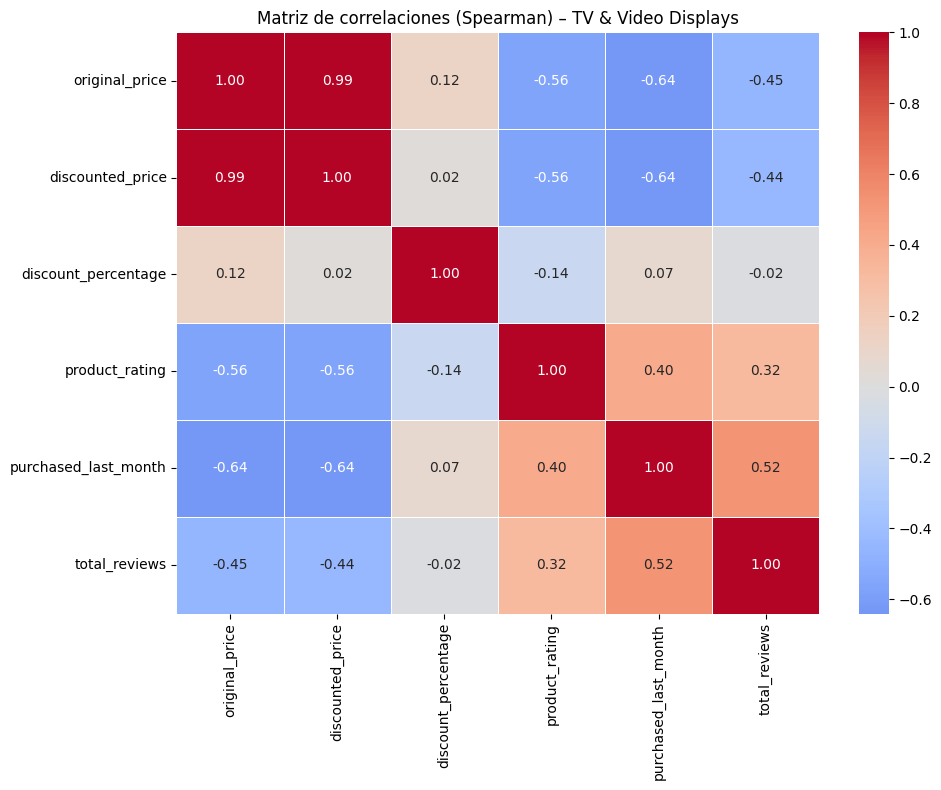

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matriz de correlaciones (Spearman) – TV & Video Displays")
plt.tight_layout()
plt.show()


## Análisis de correlaciones entre variables (Spearman)

Dado el amplio rango de precios y volúmenes de ventas presente en la categoría *TV & Video Displays*, se ha empleado el coeficiente de correlación de **Spearman**, al tratarse de una medida no paramétrica robusta frente a valores extremos. Este enfoque permite analizar relaciones monotónicas entre variables sin que los productos de gama muy alta o con ventas excepcionalmente elevadas distorsionen los resultados.

### 1. Correlaciones más significativas

**Precio original vs. precio descontado.**  
Se observa una correlación extremadamente alta entre el precio original y el precio descontado (ρ ≈ 0.99), lo que indica que ambos evolucionan prácticamente de forma conjunta. Este resultado es esperado, ya que los descuentos se aplican de forma proporcional al precio base del producto. En la matriz de correlaciones, ambas variables aparecen claramente asociadas.

**Precio vs. ventas mensuales.**  
Existe una correlación negativa moderada-alta entre el precio (original y descontado) y las ventas del último mes (ρ ≈ −0.64). Esto sugiere que los televisores y dispositivos de visualización de menor precio concentran un mayor volumen de ventas, mientras que los modelos más caros presentan una demanda sensiblemente menor.

**Ventas mensuales vs. número de reseñas.**  
La correlación positiva entre el número total de reseñas y las ventas mensuales (ρ ≈ 0.52) indica que la visibilidad social y la experiencia acumulada de otros compradores juegan un papel relevante en el rendimiento comercial de los productos de esta categoría.

### 2. Relación entre valoraciones y comportamiento de mercado

**Valoración del producto vs. ventas y reseñas.**  
La valoración media del producto muestra una correlación positiva moderada con las ventas mensuales (ρ ≈ 0.40) y con el número de reseñas (ρ ≈ 0.32). Esto sugiere que los productos mejor valorados tienden a vender más y a generar mayor interacción por parte de los usuarios, aunque este efecto no es tan determinante como el precio.

**Precio vs. valoración.**  
La correlación entre el precio y la valoración es claramente negativa (ρ ≈ −0.56), lo que indica que un mayor precio no garantiza una mejor percepción por parte del consumidor. Este resultado refleja que los productos premium están sujetos a expectativas más exigentes, mientras que modelos más económicos pueden obtener valoraciones elevadas si cumplen adecuadamente su función.

### 3. Descuentos y percepción del producto

El porcentaje de descuento presenta correlaciones muy débiles con el resto de variables, especialmente con la valoración del producto y el volumen de ventas. Esto sugiere que las rebajas, por sí solas, no determinan ni la satisfacción del cliente ni el éxito comercial, sino que actúan como un elemento complementario dentro de una estrategia más amplia.

### 4. Síntesis del análisis de correlaciones

En conjunto, la matriz de correlaciones revela que el mercado de *TV & Video Displays* está fuertemente condicionado por el precio y por la confianza generada a través de reseñas y valoraciones. Mientras que el precio actúa como una barrera clara para el volumen de ventas, la calidad percibida y la experiencia de otros usuarios contribuyen a reforzar el posicionamiento de los productos, especialmente en un contexto de elevada inversión económica como el de los dispositivos de visualización. Estos resultados respaldan la necesidad de emplear pruebas estadísticas no paramétricas en el análisis inferencial posterior.


# Tests estadísticos

In [17]:
def boot(data):
    veces = 10000   # número de medias a generar
    muestra = 300   # tamaño de cada muestra
    medias_rating = []

    for i in tqdm(range(veces)):
        muestra_i = data.sample(muestra, replace=True)   # with replacement
        medias_rating.append(muestra_i.mean())

    df_boot = pd.DataFrame({"medias": medias_rating})
    return df_boot

In [18]:
def paint(df_boot, titulo):
    plt.figure(figsize=(10,4))
    
    # Histograma
    plt.subplot(1, 2, 1)
    sns.histplot(df_boot["medias"], kde=True, bins=30, color="skyblue")
    plt.title(f"Bootstrap: {titulo}")
    
    # QQ-Plot
    plt.subplot(1, 2, 2)
    stats.probplot(df_boot["medias"], dist="norm", plot=plt)
    plt.title("QQ-Plot")
    plt.show()

In [19]:
def test_normalidad(test,grupo):
    stat, p = test(grupo)

    print("Estadístico:", stat)
    print("p-valor:", p)

    if p < 0.05:
        print("Los datos NO siguen una distribución normal.")
    else:
        print("Los datos podrían seguir una distribución normal...o no")

### Test 1 - Valoraciones según patrocinio (Sponsored vs Organic)

¿Existen diferencias significativas en la valoración de los productos según estén patrocinados o no?

In [20]:
grupo_sponsored = df_tv_and_video_displays[
    df_tv_and_video_displays['is_sponsored'] == 'Sponsored'
]['product_rating'].dropna()

grupo_organic = df_tv_and_video_displays[
    df_tv_and_video_displays['is_sponsored'] == 'Organic'
]['product_rating'].dropna()

print("Tamaño Sponsored:", len(grupo_sponsored))
print("Tamaño Organic:", len(grupo_organic))


Tamaño Sponsored: 663
Tamaño Organic: 2222


100%|██████████| 10000/10000 [00:00<00:00, 16997.96it/s]


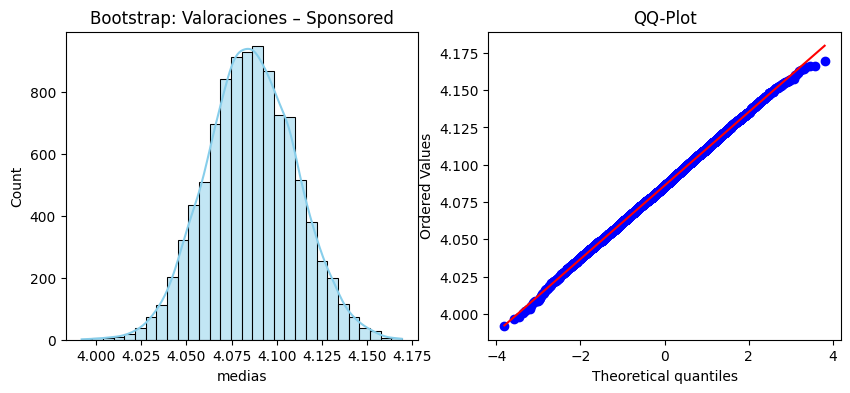

c:\Users\Daniel\Documents\GitHub\Amazon-Smart-Pricing\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.



Estadístico: 0.9997656432660498
p-valor: 0.3397510327832135
Los datos podrían seguir una distribución normal...o no


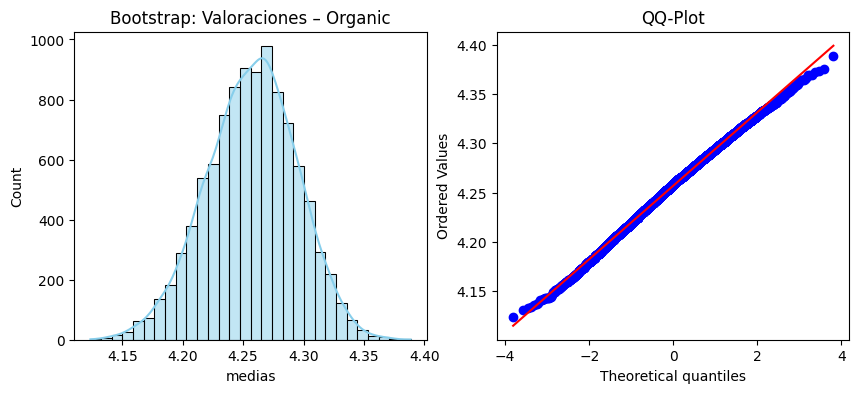

Estadístico: 0.9984440067116197
p-valor: 2.115911783165102e-08
Los datos NO siguen una distribución normal.


c:\Users\Daniel\Documents\GitHub\Amazon-Smart-Pricing\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.



In [21]:
df_boot_sponsored = boot(grupo_sponsored)
df_boot_organic = boot(grupo_organic)

paint(df_boot_sponsored, "Valoraciones – Sponsored")
test_normalidad(stats.shapiro, df_boot_sponsored["medias"])

paint(df_boot_organic, "Valoraciones – Organic")
test_normalidad(stats.shapiro, df_boot_organic["medias"])


In [22]:
stat_lev, p_lev = stats.levene(grupo_sponsored, grupo_organic)
print("\nTest de Levene (varianzas)")
print("Estadístico:", stat_lev)
print("p-valor:", p_lev)



Test de Levene (varianzas)
Estadístico: 0.09765402094541129
p-valor: 0.7546858737315629


In [23]:
print("Desviación típica Sponsored:", grupo_sponsored.std())
print("Desviación típica Organic:", grupo_organic.std())


Desviación típica Sponsored: 0.4316851999336038
Desviación típica Organic: 0.65692643514049


H₀: No existen diferencias significativas en la valoración media de los productos patrocinados y no patrocinados.

H₁: Existen diferencias significativas en la valoración media entre productos patrocinados y no patrocinados.


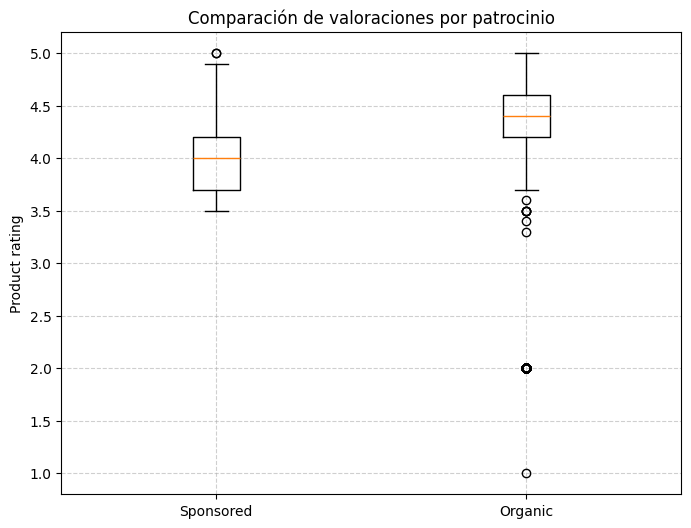


Mann–Whitney U (Rating: Sponsored vs Organic)
Estadístico U: 463642.00
p-valor: 0.000000
Se rechaza H₀: existen diferencias significativas.


In [24]:
plt.figure(figsize=(8,6))
plt.boxplot([grupo_sponsored, grupo_organic], tick_labels=["Sponsored", "Organic"])
plt.title("Comparación de valoraciones por patrocinio")
plt.ylabel("Product rating")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

stat, p = mannwhitneyu(grupo_sponsored, grupo_organic, alternative='two-sided')

print("\nMann–Whitney U (Rating: Sponsored vs Organic)")
print(f"Estadístico U: {stat:.2f}")
print(f"p-valor: {p:.6f}")

if p < 0.05:
    print("Se rechaza H₀: existen diferencias significativas.")
else:
    print("No se rechaza H₀: no se detectan diferencias significativas.")


## Test 1 – Diferencias en las valoraciones según patrocinio

En este test se analiza si existen diferencias estadísticamente significativas en la **valoración media de los productos** en función de si estos están **patrocinados (Sponsored)** o aparecen de forma **orgánica (Organic)** en Amazon dentro de la categoría *TV & Video Displays*.

### Planteamiento de hipótesis

- **H₀ (Hipótesis nula):**  
  No existen diferencias significativas en la valoración media de los productos patrocinados y no patrocinados.

- **H₁ (Hipótesis alternativa):**  
  Existen diferencias significativas en la valoración media entre productos patrocinados y no patrocinados.

### Análisis previo de normalidad

Debido al tamaño muestral y a la posible presencia de valores atípicos, se ha aplicado un **procedimiento bootstrap** sobre la media de la variable *product_rating* para ambos grupos.

Los histogramas y los QQ-plots sugieren una distribución aproximadamente simétrica de las medias bootstrap. Sin embargo, el **test de Shapiro-Wilk** muestra que:

- Para los productos *Sponsored* no se puede rechazar claramente la normalidad.
- Para los productos *Organic* se rechaza la hipótesis de normalidad.

Dado que **no se cumple la normalidad en ambos grupos de forma consistente**, se opta por utilizar pruebas **no paramétricas** en el contraste principal.

### Homogeneidad de varianzas

Se ha aplicado el **test de Levene** para evaluar la igualdad de varianzas entre ambos grupos, sin asumir normalidad:

- El p-valor obtenido es superior a 0.05, por lo que **no se rechaza la hipótesis de igualdad de varianzas**.
- No obstante, se observa que el grupo *Organic* presenta una desviación típica mayor, lo que indica una mayor dispersión en sus valoraciones.

### Contraste de hipótesis: Test de Mann–Whitney U

Dado que:
- No se puede asumir normalidad,
- Las muestras son independientes,
- La variable analizada es ordinal/continua (*product_rating*),

se ha aplicado el **test de Mann–Whitney U** para comparar las valoraciones de los productos patrocinados y orgánicos.

El resultado del test arroja un **p-valor prácticamente nulo**, lo que permite **rechazar la hipótesis nula** con un alto nivel de significación estadística.

### Conclusión

Existe evidencia estadística suficiente para afirmar que **las valoraciones de los productos patrocinados y no patrocinados son significativamente diferentes** en la categoría *TV & Video Displays*.  

Este resultado sugiere que el patrocinio está asociado a una percepción distinta por parte de los usuarios, posiblemente influida por factores como la visibilidad del producto, las expectativas del consumidor o estrategias comerciales específicas. No obstante, este análisis no permite establecer relaciones causales, sino únicamente asociaciones estadísticas.


### Test 2 – Ventas según patrocinio (Sponsored vs Organic)

In [25]:
grupo_sponsored_sales = df_tv_and_video_displays[
    df_tv_and_video_displays['is_sponsored'] == 'Sponsored'
]['purchased_last_month'].dropna()

grupo_organic_sales = df_tv_and_video_displays[
    df_tv_and_video_displays['is_sponsored'] == 'Organic'
]['purchased_last_month'].dropna()

print("Tamaño Sponsored:", len(grupo_sponsored_sales))
print("Tamaño Organic:", len(grupo_organic_sales))


Tamaño Sponsored: 84
Tamaño Organic: 2002


100%|██████████| 10000/10000 [00:00<00:00, 18191.55it/s]


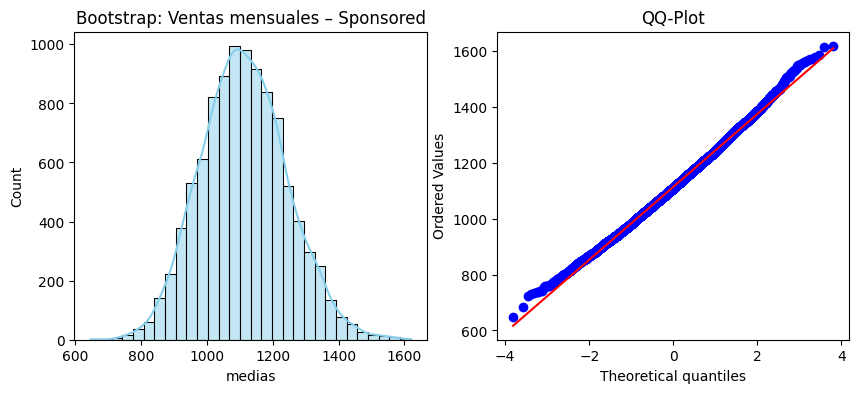

c:\Users\Daniel\Documents\GitHub\Amazon-Smart-Pricing\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.



Estadístico: 0.9978156935748408
p-valor: 8.3534992577916e-11
Los datos NO siguen una distribución normal.


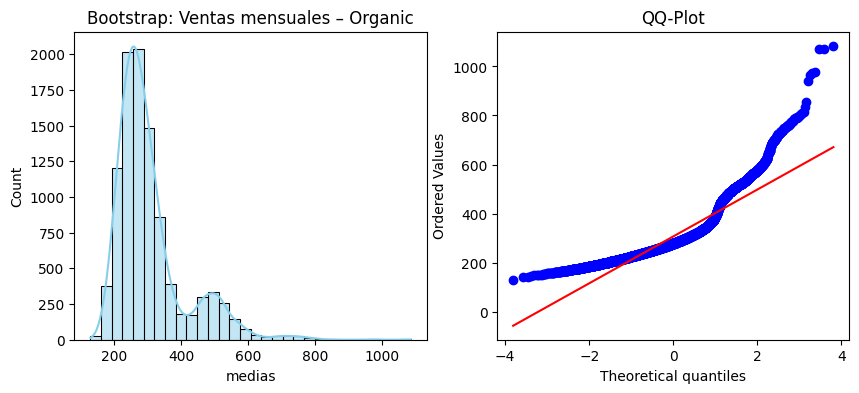

Estadístico: 0.8368426528143361
p-valor: 3.075508262364911e-72
Los datos NO siguen una distribución normal.


c:\Users\Daniel\Documents\GitHub\Amazon-Smart-Pricing\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.



In [26]:
df_boot_sponsored_sales = boot(grupo_sponsored_sales)
df_boot_organic_sales = boot(grupo_organic_sales)

paint(df_boot_sponsored_sales, "Ventas mensuales – Sponsored")
test_normalidad(stats.shapiro, df_boot_sponsored_sales["medias"])

paint(df_boot_organic_sales, "Ventas mensuales – Organic")
test_normalidad(stats.shapiro, df_boot_organic_sales["medias"])


In [27]:
stat_lev, p_lev = stats.levene(grupo_sponsored_sales, grupo_organic_sales)

print("\nTest de Levene (varianzas)")
print("Estadístico:", stat_lev)
print("p-valor:", p_lev)

print("Desviación típica Sponsored:", grupo_sponsored_sales.std())
print("Desviación típica Organic:", grupo_organic_sales.std())



Test de Levene (varianzas)
Estadístico: 4.667116352625367
p-valor: 0.030859169983148547
Desviación típica Sponsored: 2273.9564193057645
Desviación típica Organic: 1796.574814108901


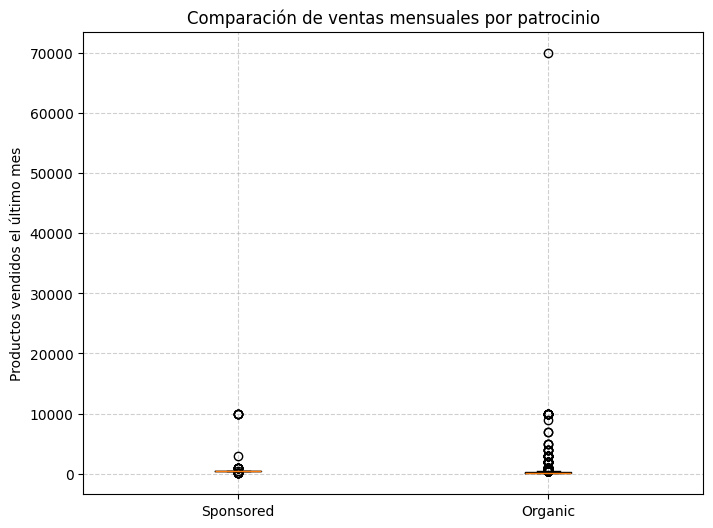

In [28]:
plt.figure(figsize=(8,6))
plt.boxplot(
    [grupo_sponsored_sales, grupo_organic_sales],
    tick_labels=["Sponsored", "Organic"]
)
plt.title("Comparación de ventas mensuales por patrocinio")
plt.ylabel("Productos vendidos el último mes")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [29]:
stat, p = mannwhitneyu(
    grupo_sponsored_sales,
    grupo_organic_sales,
    alternative='two-sided'
)

print("\nMann–Whitney U (Ventas: Sponsored vs Organic)")
print(f"Estadístico U: {stat:.2f}")
print(f"p-valor: {p:.6f}")

if p < 0.05:
    print("Se rechaza H₀: existen diferencias significativas en las ventas.")
else:
    print("No se rechaza H₀: no se detectan diferencias significativas.")



Mann–Whitney U (Ventas: Sponsored vs Organic)
Estadístico U: 150732.00
p-valor: 0.000000
Se rechaza H₀: existen diferencias significativas en las ventas.


### Test 2 – Ventas según patrocinio (Sponsored vs Organic)

En este segundo test se analiza si existen diferencias estadísticamente significativas en el volumen de ventas mensuales (*purchased_last_month*) entre los productos patrocinados y los productos orgánicos dentro de la categoría *TV & Video Displays*.

#### 1. Análisis de normalidad

Mediante bootstrap de la media y el test de Shapiro-Wilk se comprueba que, en ambos grupos (Sponsored y Organic), las distribuciones de las medias no siguen una distribución normal (p-valor <> 0.05). Este resultado era esperable dado el fuerte sesgo y la presencia de valores extremos en la variable de ventas mensuales.

Por tanto, no es adecuado emplear contrastes paramétricos basados en normalidad.

#### 2. Homogeneidad de varianzas

El test de Levene muestra un p-valor inferior a 0.05, lo que indica que las varianzas de ambos grupos son significativamente diferentes. Además, la desviación típica de las ventas en productos patrocinados es superior a la de los productos orgánicos, reflejando una mayor dispersión y presencia de valores extremos en este grupo.

#### 3. Contraste de hipótesis

Se plantean las siguientes hipótesis:

- **H₀:** No existen diferencias significativas en las ventas mensuales entre productos patrocinados y orgánicos.  
- **H₁:** Existen diferencias significativas en las ventas mensuales entre productos patrocinados y orgánicos.

Dado que no se cumplen los supuestos de normalidad ni de homocedasticidad, se aplica el test no paramétrico de **Mann–Whitney U**.

El resultado del contraste arroja un p-valor prácticamente nulo (p < 0.05), lo que permite **rechazar la hipótesis nula**.

#### 4. Interpretación de resultados

Los resultados indican que existen diferencias estadísticamente significativas en las ventas mensuales entre los productos patrocinados y los productos orgánicos. En particular, los productos patrocinados presentan una mayor dispersión y concentran algunos de los valores de ventas más elevados, lo que sugiere que el patrocinio puede incrementar la visibilidad y favorecer picos de ventas en determinados productos.

No obstante, la presencia de outliers extremos y la elevada heterogeneidad del grupo patrocinado indican que este efecto no es homogéneo para todos los productos, sino que beneficia principalmente a un subconjunto reducido de ellos.


### Test 3 - Precio según patrocinio (Sponsored vs Oragnic)

In [30]:
### Test 3 – Precio según patrocinio (Sponsored vs Organic)

grupo_sponsored_price = df_tv_and_video_displays[
    df_tv_and_video_displays['is_sponsored'] == 'Sponsored'
]['original_price'].dropna()

grupo_organic_price = df_tv_and_video_displays[
    df_tv_and_video_displays['is_sponsored'] == 'Organic'
]['original_price'].dropna()

print("Tamaño Sponsored:", len(grupo_sponsored_price))
print("Tamaño Organic:", len(grupo_organic_price))


Tamaño Sponsored: 666
Tamaño Organic: 2164


100%|██████████| 10000/10000 [00:00<00:00, 14784.79it/s]


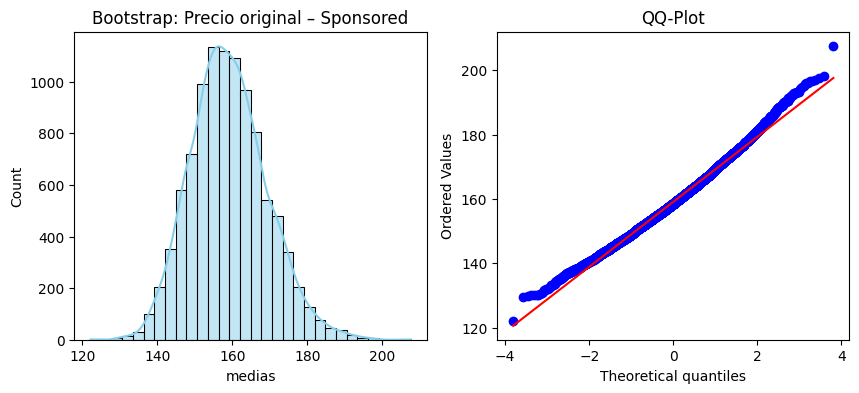

c:\Users\Daniel\Documents\GitHub\Amazon-Smart-Pricing\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.



Estadístico: 0.9936540774413047
p-valor: 1.1868086926061141e-20
Los datos NO siguen una distribución normal.


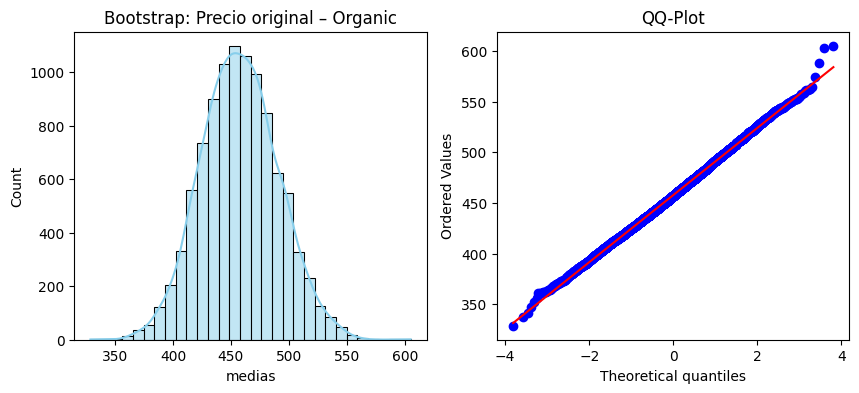

Estadístico: 0.999229147707465
p-valor: 0.0001587439409732494
Los datos NO siguen una distribución normal.


c:\Users\Daniel\Documents\GitHub\Amazon-Smart-Pricing\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.



In [31]:
# Bootstrap
df_boot_sponsored_price = boot(grupo_sponsored_price)
df_boot_organic_price = boot(grupo_organic_price)

paint(df_boot_sponsored_price, "Precio original – Sponsored")
test_normalidad(stats.shapiro, df_boot_sponsored_price["medias"])

paint(df_boot_organic_price, "Precio original – Organic")
test_normalidad(stats.shapiro, df_boot_organic_price["medias"])


In [32]:
# Test de Levene
stat_lev, p_lev = stats.levene(grupo_sponsored_price, grupo_organic_price)

print("\nTest de Levene (varianzas)")
print("Estadístico:", stat_lev)
print("p-valor:", p_lev)

print("Desviación típica Sponsored:", grupo_sponsored_price.std())
print("Desviación típica Organic:", grupo_organic_price.std())



Test de Levene (varianzas)
Estadístico: 154.56487939859412
p-valor: 1.373720799773851e-34
Desviación típica Sponsored: 175.87380171394767
Desviación típica Organic: 573.2442981930009


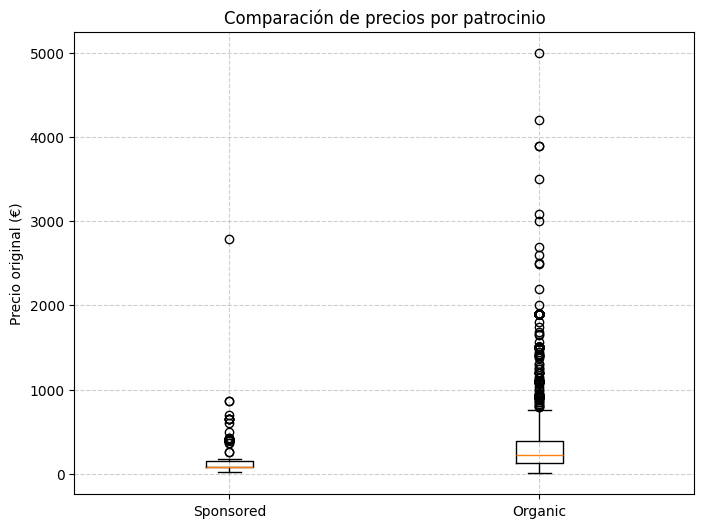

In [33]:
# Boxplot
plt.figure(figsize=(8,6))
plt.boxplot(
    [grupo_sponsored_price, grupo_organic_price],
    tick_labels=["Sponsored", "Organic"]
)
plt.title("Comparación de precios por patrocinio")
plt.ylabel("Precio original (€)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [34]:
# Mann–Whitney U
stat, p = mannwhitneyu(
    grupo_sponsored_price,
    grupo_organic_price,
    alternative='two-sided'
)

print("\nMann–Whitney U (Precio: Sponsored vs Organic)")
print(f"Estadístico U: {stat:.2f}")
print(f"p-valor: {p:.6f}")

if p < 0.05:
    print("Se rechaza H₀: existen diferencias significativas en el precio.")
else:
    print("No se rechaza H₀: no se detectan diferencias significativas.")



Mann–Whitney U (Precio: Sponsored vs Organic)
Estadístico U: 442521.50
p-valor: 0.000000
Se rechaza H₀: existen diferencias significativas en el precio.


### Test 3 – Precio según patrocinio (Sponsored vs Organic)

En este tercer test se analiza si existen diferencias significativas en el **precio original** de los productos de la categoría *TV & Video Displays* en función de si estos están patrocinados (*Sponsored*) o no (*Organic*).

#### Planteamiento de hipótesis

- **H₀:** No existen diferencias significativas en el precio original de los productos patrocinados y no patrocinados.  
- **H₁:** Existen diferencias significativas en el precio original entre productos patrocinados y no patrocinados.

#### Análisis previo y supuestos

Mediante técnicas de *bootstrap* se ha estudiado la distribución de las medias del precio original en ambos grupos. Los histogramas y QQ-plots muestran desviaciones claras respecto a la normalidad, lo que queda confirmado por el test de Shapiro–Wilk, que rechaza la hipótesis de normalidad en ambos casos.

Adicionalmente, el test de Levene indica que las varianzas de ambos grupos son significativamente diferentes (p ≪ 0.05). Este resultado, junto con la presencia de valores extremos y una fuerte asimetría en la distribución de precios, justifica el uso de una prueba no paramétrica para la comparación entre grupos.

#### Comparación entre grupos

Se ha aplicado el test **Mann–Whitney U**, adecuado para comparar dos muestras independientes sin asumir normalidad ni igualdad de varianzas. El resultado del test permite **rechazar la hipótesis nula**, indicando la existencia de diferencias estadísticamente significativas en el precio original entre productos patrocinados y no patrocinados.

El análisis gráfico mediante diagramas de caja refuerza este resultado, mostrando que los productos orgánicos presentan, en general, precios más elevados y una dispersión mucho mayor, con la presencia de numerosos productos de gama alta. Por el contrario, los productos patrocinados se concentran mayoritariamente en rangos de precio más bajos y homogéneos.

#### Conclusión del test

Los resultados sugieren que el patrocinio en la categoría *TV & Video Displays* está asociado a productos con precios significativamente inferiores. Esto indica que las estrategias de patrocinio se orientan principalmente hacia productos más accesibles, probablemente con el objetivo de maximizar volumen de ventas y visibilidad, mientras que los productos de gama alta tienden a posicionarse de forma orgánica.
